In [2]:
import pandas as pd
import os
from pathlib import Path

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """loads data from a csv file and returns a pandas DataFrame"""
    df = pd.read_csv(path)
    return df


def load_customers() -> pd.DataFrame:
    """loads customer data from the subject folder and returns a pandas DataFrame"""
    dfs = []
    base_path = Path.cwd()
    data_path = (base_path / "../subject/customer").resolve()

    if not data_path.exists():
        print(f"Directory not found: {data_path}")
        return

    for file in data_path.glob("*.csv"):
        dfs.append(pd.read_csv(file))
        
    contacts = pd.concat(dfs)
    contacts['event_time'] = pd.to_datetime(contacts['event_time'])
    return contacts


def load_items():
    """loads item data from the subject folder and returns a pandas DataFrame"""
    df = load_data("../subject/item/item.csv")
    return df


def merge_data(items, customers) -> pd.DataFrame:
    """merges the customer and item dataframes on the product_id column and returns a new DataFrame"""
    df = pd.merge(customers, items, on="product_id")
    return df


def remove_doubles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Removes rows where the same product, event, and user session 
    occur within 1 second of each other.
    """
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])
    
    sort_cols = ['user_id', 'product_id', 'event_type', 'event_time']
    df = df.sort_values(by=sort_cols)
    
    group_cols = ['user_id', 'product_id', 'event_type']
    time_diff = df.groupby(group_cols)['event_time'].diff()
    
    mask = (time_diff > pd.Timedelta(seconds=1)) | (time_diff.isna())
    
    return df[mask].reset_index(drop=True)

In [4]:
customers = load_customers()
customers = remove_doubles(customers)
items = load_items()
customers = merge_data(items, customers)

In [5]:
customers.head()

,event_time,event_type,product_id,price,user_id,user_session,category_id,category_code,brand
0,2023-01-14 16:25:35+00:00,view,5769989,10.0,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c,1.487580e+18,NaN,cnd
1,2023-01-14 16:25:35+00:00,view,5769989,10.0,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c,NaN,NaN,NaN
2,2023-01-27 14:31:24+00:00,view,5769989,10.0,77946977,6e9dd44d-c489-4056-a050-697fb8156da4,1.487580e+18,NaN,cnd
3,2023-01-27 14:31:24+00:00,view,5769989,10.0,77946977,6e9dd44d-c489-4056-a050-697fb8156da4,NaN,NaN,NaN
4,2023-01-28 19:44:35+00:00,view,5769989,10.0,77946977,803cb333-fbd4-5080-3a37-b02a0b7882ab,1.487580e+18,NaN,cnd


In [21]:
frequency = customers[customers['event_type'] == "purchase"]
frequency = frequency.groupby("user_id").size().reset_index(name="purchase_count")
frequency.head()

,user_id,purchase_count
0,9794320,12
1,10079204,5
2,10280338,41
3,12055855,10
4,12936739,5


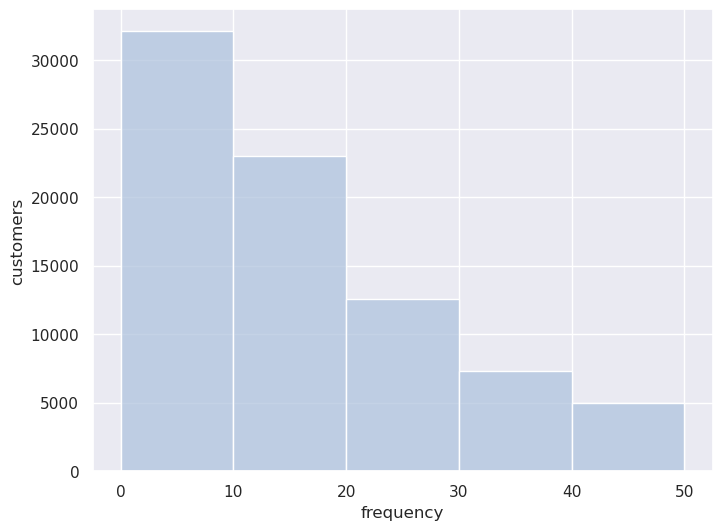

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid") 

plt.figure(figsize=(8, 6))
sns.histplot(
    frequency['purchase_count'], 
    bins=[0, 10, 20, 30, 40, 50], 
    color='lightsteelblue', 
    edgecolor='white'
)

plt.xlabel('frequency')
plt.ylabel('customers')

plt.xticks([0, 10, 20, 30, 40, 50])

plt.show()

In [14]:
monetary = customers[customers['event_type'] == "purchase"]
monetary = monetary.groupby("user_id")["price"].sum().reset_index(name="total_spent")
monetary.head()

,user_id,total_spent
0,9794320,38.04
1,10079204,65.18
2,10280338,186.70
3,12055855,42.05
4,12936739,86.75


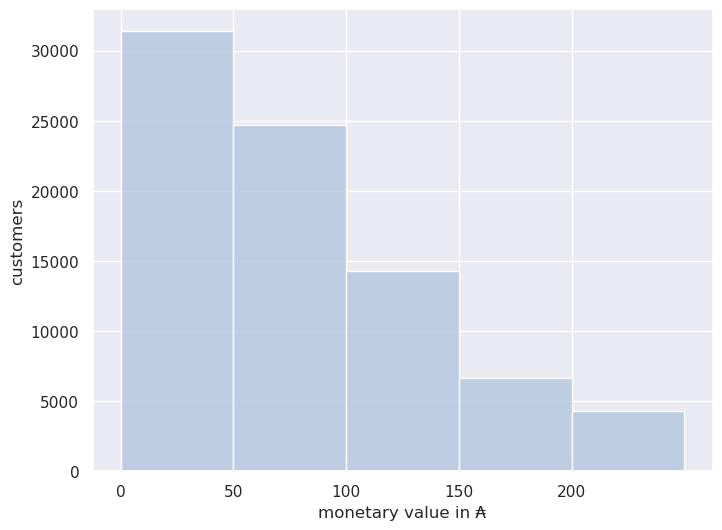

In [19]:
sns.set_theme(style="darkgrid") 

plt.figure(figsize=(8, 6))
sns.histplot(
    monetary['total_spent'], 
    bins=[0, 50, 100, 150, 200, 250], 
    color='lightsteelblue', 
    edgecolor='white'
)

plt.xlabel('monetary value in ₳')
plt.ylabel('customers')

plt.xticks([0, 50, 100, 150, 200])

plt.show()